# Heart Disease Predictor

In [1]:
!pip install plotly

In [2]:
# Installing required libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Loading the dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
heart_df = pd.read_csv('/content/drive/MyDrive/Datasets/heart.csv')
heart_df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [5]:
heart_df.sample(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
735,49,M,NAP,120,188,0,Normal,139,N,2.0,Flat,1
275,59,M,NAP,180,213,0,Normal,100,N,0.0,Up,0
132,56,M,ASY,170,388,0,ST,122,Y,2.0,Flat,1
475,59,M,ASY,178,0,1,LVH,120,Y,0.0,Flat,1
320,59,M,NAP,125,0,1,Normal,175,N,2.6,Flat,1


In [6]:
# Getting dataset summary
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [7]:
# Displaying the statistics of the dataset
heart_df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [8]:
heart_df.describe(include='all')

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918,918,918.000000,918.000000,918.000000,918,918.000000,918,918.000000,918,918.000000
unique,NaN,2,4,NaN,NaN,NaN,3,NaN,2,NaN,3,NaN
top,NaN,M,ASY,NaN,NaN,NaN,Normal,NaN,N,NaN,Flat,NaN
freq,NaN,725,496,NaN,NaN,NaN,552,NaN,547,NaN,460,NaN
mean,53.510893,NaN,NaN,132.396514,198.799564,0.233115,NaN,136.809368,NaN,0.887364,NaN,0.553377
std,9.432617,NaN,NaN,18.514154,109.384145,0.423046,NaN,25.460334,NaN,1.066570,NaN,0.497414
min,28.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,60.000000,NaN,-2.600000,NaN,0.000000
25%,47.000000,NaN,NaN,120.000000,173.250000,0.000000,NaN,120.000000,NaN,0.000000,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,223.000000,0.000000,NaN,138.000000,NaN,0.600000,NaN,1.000000
75%,60.000000,NaN,NaN,140.000000,267.000000,0.000000,NaN,156.000000,NaN,1.500000,NaN,1.000000


# Data Preprocessing

In [9]:
# Checking null values
heart_df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


In [10]:
# Checking duplicated values
heart_df.duplicated().sum()

np.int64(0)

In [11]:
# Checking no.of unique value in each feature
heart_df.nunique()

,0
Age,50
Sex,2
ChestPainType,4
RestingBP,67
Cholesterol,222
FastingBS,2
RestingECG,3
MaxHR,119
ExerciseAngina,2
Oldpeak,53


In [12]:
heart_df.select_dtypes(include='object').columns

Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')

In [13]:
categorical_col = heart_df.select_dtypes(include='object').columns

In [14]:
heart_df['ChestPainType'].unique()

array(['ATA', 'NAP', 'ASY', 'TA'], dtype=object)

In [15]:
range(heart_df['ChestPainType'].nunique())

range(0, 4)

# Converting Categorical Variables to Numeric

* Sex: M=0, F=1

* ChestPainType: ATA=0, NAP=1, ASY=2, TA=3

* RestingECG: Normal=0, ST=1, LVH=2

* ExerciseAngina: N=0, Y=1

* ST_Slope: Up=0, Flat=1, Down=2

In [16]:
for col in categorical_col:
  print(col)
  print((heart_df[col].unique()), list(range(heart_df[col].nunique())))
  heart_df[col].replace((heart_df[col].unique()), range(heart_df[col].nunique()), inplace=True)
  print('*'*90)
  print()

Sex
['M' 'F'] [0, 1]
******************************************************************************************

ChestPainType
['ATA' 'NAP' 'ASY' 'TA'] [0, 1, 2, 3]
******************************************************************************************

RestingECG
['Normal' 'ST' 'LVH'] [0, 1, 2]
******************************************************************************************

ExerciseAngina
['N' 'Y'] [0, 1]
******************************************************************************************

ST_Slope
['Up' 'Flat' 'Down'] [0, 1, 2]
******************************************************************************************



In [17]:
heart_df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,0,140,289,0,0,172,0,0.0,0,0
1,49,1,1,160,180,0,0,156,0,1.0,1,1
2,37,0,0,130,283,0,1,98,0,0.0,0,0
3,48,1,2,138,214,0,0,108,1,1.5,1,1
4,54,0,1,150,195,0,0,122,0,0.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,0,3,110,264,0,0,132,0,1.2,1,1
914,68,0,2,144,193,1,0,141,0,3.4,1,1
915,57,0,2,130,131,0,0,115,1,1.2,1,1
916,57,1,0,130,236,0,2,174,0,0.0,1,1


Cholesterol cannot be 0, it states that the reading was not properly noted

In [18]:
heart_df['Cholesterol'].value_counts()

,count
Cholesterol,
0,172
254,11
220,10
223,10
204,9
...,...
353,1
278,1
157,1


# Imputing the 0 values in Cholesterol column with KNN Imputer

In [19]:
np.nan

nan

In [20]:
heart_df['Cholesterol'].replace(0, np.nan, inplace=True)

In [21]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=3)
after_impute =imputer.fit_transform(heart_df)
heart_df = pd.DataFrame(after_impute, columns=heart_df.columns)

In [22]:
heart_df['Cholesterol'].isnull().sum()

np.int64(0)

In [23]:
count = 0
for i in heart_df['Cholesterol']:
  if i == 0:
    count += 1
print(count)

0


# Doing the same for Resting Blood Pressure

In [24]:
heart_df['RestingBP'][heart_df['RestingBP'] == 0]

,RestingBP
449,0.0


In [25]:
from sklearn.impute import KNNImputer
heart_df['RestingBP'].replace(0, np.nan, inplace=True)
imputer = KNNImputer(n_neighbors=3)
after_impute =imputer.fit_transform(heart_df)
heart_df = pd.DataFrame(after_impute, columns=heart_df.columns)

In [26]:
heart_df['RestingBP'].unique()

array([140., 160., 130., 138., 150., 120., 110., 136., 115., 100., 124.,
       113., 125., 145., 112., 132., 118., 170., 142., 190., 135., 180.,
       108., 155., 128., 106.,  92., 200., 122.,  98., 105., 133.,  95.,
        80., 137., 185., 165., 126., 152., 116., 144., 154., 134., 104.,
       139., 131., 141., 178., 146., 158., 123., 102.,  96., 143., 172.,
       156., 114., 127., 101., 174.,  94., 148., 117., 192., 129., 164.])

In [27]:
heart_df['RestingBP'].isnull().sum()

np.int64(0)

# Change columns type to int

In [28]:
withoutOldPeak = heart_df.columns
withoutOldPeak = withoutOldPeak.drop('Oldpeak')
heart_df[withoutOldPeak] = heart_df[withoutOldPeak].astype('int32')

In [29]:
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int32  
 1   Sex             918 non-null    int32  
 2   ChestPainType   918 non-null    int32  
 3   RestingBP       918 non-null    int32  
 4   Cholesterol     918 non-null    int32  
 5   FastingBS       918 non-null    int32  
 6   RestingECG      918 non-null    int32  
 7   MaxHR           918 non-null    int32  
 8   ExerciseAngina  918 non-null    int32  
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    int32  
 11  HeartDisease    918 non-null    int32  
dtypes: float64(1), int32(11)
memory usage: 46.7 KB


# Data Visualization

In [30]:
heart_df.sample()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
154,41,0,0,120,291,0,1,160,0,0.0,0,0


In [31]:
heart_df.corr()['HeartDisease'][:-1].sort_values()

,HeartDisease
MaxHR,-0.400421
Sex,-0.305445
RestingECG,0.061011
Cholesterol,0.101263
RestingBP,0.118333
FastingBS,0.267291
Age,0.282039
Oldpeak,0.403951
ChestPainType,0.459017
ExerciseAngina,0.494282


Plotly provides interactive visualizations which help in better data exploration.

Plotly → Interactive graphs

Plotly was used because it provides interactive and visually appealing graphs, supports advanced visualizations like sunburst charts, and is more suitable for presentations compared to static libraries like Matplotlib and Seaborn.

In [32]:
import plotly.express as px

In [33]:
px.line(heart_df.corr()['HeartDisease'][:-1].sort_values())

# Age and HeartDisease Distribution

In [34]:
px.sunburst(heart_df, path=['HeartDisease', 'Age'])

In [35]:
px.histogram(heart_df, x='Age', color='HeartDisease')

# Percentage of HeartDisease data distribution

In [36]:
px.pie(heart_df, names='HeartDisease', title='Percentage of HeartDisease class distribution')

# Sex Vs HeartDisease

In [37]:
px.histogram(heart_df, x='Sex', color='HeartDisease')

# ChestPainType Vs HeartDisease

In [38]:
px.histogram(heart_df, x='ChestPainType', color='HeartDisease')

# RestingBP Vs HeartDisease

In [39]:
heart_df['RestingBP'].unique()

array([140, 160, 130, 138, 150, 120, 110, 136, 115, 100, 124, 113, 125,
       145, 112, 132, 118, 170, 142, 190, 135, 180, 108, 155, 128, 106,
        92, 200, 122,  98, 105, 133,  95,  80, 137, 185, 165, 126, 152,
       116, 144, 154, 134, 104, 139, 131, 141, 178, 146, 158, 123, 102,
        96, 143, 172, 156, 114, 127, 101, 174,  94, 148, 117, 192, 129,
       164], dtype=int32)

In [40]:
px.sunburst(heart_df, path=['HeartDisease', 'RestingBP'])

# FastingBS Vs HeartDisease

In [41]:
px.histogram(heart_df, x='FastingBS', color='HeartDisease')

# MaxHR Vs HeartDisease

In [42]:
px.sunburst(heart_df, path=['HeartDisease', 'MaxHR'])

In [43]:
px.violin(heart_df, x='HeartDisease', y='MaxHR', color='HeartDisease')

# Oldpeak Vs HeartDisease

In [44]:
px.violin(heart_df, x='HeartDisease', y='Oldpeak', color='HeartDisease')

# ST_Slope Vs HeartDisease

In [45]:
px.histogram(heart_df, x='ST_Slope', color='HeartDisease')

# ExerciseAngina Vs HeartDisease

In [46]:
px.histogram(heart_df, x='ExerciseAngina', color='HeartDisease')

# Train Test Split

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    heart_df.drop('HeartDisease', axis=1),
    heart_df['HeartDisease'],
    test_size = 0.2,
    random_state = 42,
    stratify = heart_df['HeartDisease']
)

# Model Training

# Logistic Regression

In [48]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

solver = ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga']
best_solver = ''
test_score = np.zeros(6)
for i,n in enumerate(solver):
  lr = LogisticRegression(solver=n).fit(X_train, y_train)
  test_score[i] = lr.score(X_test, y_test)
  if lr.score(X_test, y_test) == max(test_score):
    best_solver = n

print(best_solver)
lr = LogisticRegression(solver=best_solver).fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print(f'LogisticRegression Score: {accuracy_score(y_test, lr_pred)}')

newton-cholesky
LogisticRegression Score: 0.8586956521739131


# Support Vector Machine(SVM)

In [49]:
from sklearn.svm import SVC
from sklearn.metrics import f1_score

kernels = {'linear':0, 'poly':0, 'rbf':0, 'sigmoid':0}
best = ''
for i in kernels:
  svm = SVC(kernel=i).fit(X_train, y_train)
  yhat = svm.predict(X_test)
  kernels[i] = f1_score(y_test, yhat, average='weighted')
  if kernels[i] == max(kernels.values()):
    best = i

print(best)
svm = SVC(kernel=best).fit(X_train, y_train)
svm_pred = svm.predict(X_test)
print(f'SVM f1_score kernel({best}): {f1_score(y_test, svm_pred, average='weighted')}')

linear
SVM f1_score kernel(linear): 0.8422922535440344


# Decision Tree Classifier

In [50]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dtree = DecisionTreeClassifier(class_weight='balanced')
param_grid = {
    'max_depth': [3, 4, 5, 6, 7, 8],
    'min_samples_split': [2, 3, 4],
    'min_samples_leaf': [1, 2, 3, 4],
    'random_state': [0, 42]
}
grid_search = GridSearchCV(estimator=dtree, param_grid=param_grid, cv=5).fit(X_train, y_train)
Ctree = DecisionTreeClassifier(**grid_search.best_params_, class_weight='balanced').fit(X_train, y_train)
dtc_pred = Ctree.predict(X_test)
print(f'DecisionTreeClassifier Score: {accuracy_score(y_test, dtc_pred)}')

DecisionTreeClassifier Score: 0.8097826086956522


# Random Forest Classifier

In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

rfc = RandomForestClassifier(class_weight='balanced')
param_grid = {
    'n_estimators': [50, 100, 150, 500],
    'max_features': ['sqrt', 'log2', None],
    'max_depth': [3, 6, 9, 20],
    'max_leaf_nodes': [3, 6, 9]
}
grid_search = GridSearchCV(rfc, param_grid=param_grid).fit(X_train, y_train)
rfctree = RandomForestClassifier(**grid_search.best_params_, class_weight='balanced').fit(X_train, y_train)
rfc_pred = rfctree.predict(X_test)
print(f'RandomForestClassifier Score: {accuracy_score(y_test, rfc_pred)}')

RandomForestClassifier Score: 0.8586956521739131


Feature Importance helps identify which medical parameters contribute most to heart disease prediction.

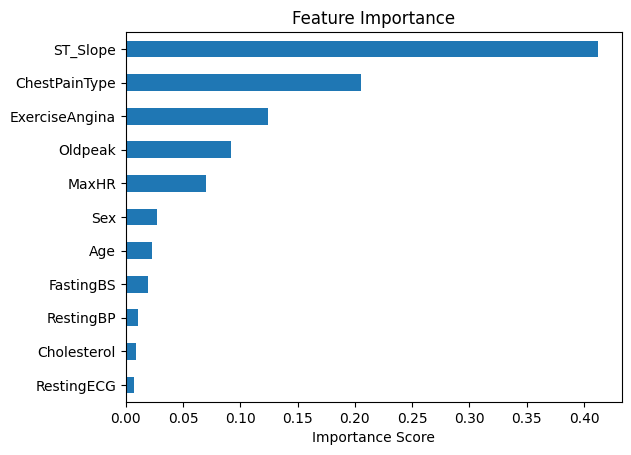

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(rfctree.feature_importances_, index=X_train.columns)

feature_importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

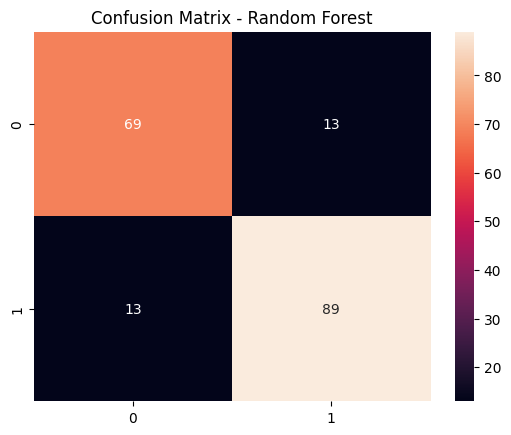

In [52]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rfc_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()

**Conclusion**

* The Heart Disease Prediction system was successfully developed using machine learning techniques.

* The dataset was effectively preprocessed by handling missing values (using KNN Imputer) and encoding categorical features.

* Exploratory Data Analysis (EDA) using visualizations like histograms, sunburst charts, and correlation plots helped in understanding the data distribution and relationships.

* Multiple models such as Logistic Regression, Support Vector Machine (SVM), Decision Tree, and Random Forest were implemented and compared.

* Hyperparameter tuning using GridSearchCV improved model performance and ensured better generalization.

* Among all models, Random Forest achieved better performance due to its ensemble learning capability and robustness against overfitting.

* Evaluation metrics like accuracy and F1-score confirmed that the model can reliably predict heart disease.

* Feature importance analysis highlighted the most influential medical parameters in prediction.

* The project demonstrates how machine learning can assist in early detection of heart disease and support healthcare decision-making.